In [5]:
import pandas as pd

df1 = pd.read_excel('FinTrust_Customer_Data.xlsx')
df2 = pd.read_excel('FinTrust_Transaction_Data.xlsx')

**Customer Data Inspection**

In [7]:
print(df1.head())
print(df1.shape)

  Customer_ID     Customer_Name  Age  Gender           City Customer_Segment  \
0   FT-C00001   Ibrahim Adeyemi   56    Male          Lagos          Premium   
1   FT-C00002    Yusuf Mohammed   46    Male           Kano         Everyday   
2   FT-C00003     Emeka Adeyemi   32  Female  Port Harcourt         Everyday   
3   FT-C00004    David Williams   60  Female     Benin City          Premium   
4   FT-C00005  Blessing Adeyemi   25    Male         Kaduna          Premium   

  Account_Type  Tenure_Months  Digital_Engagement_Score Monthly_Income_Band  \
0      Savings             55                      84.9           500k-999k   
1      Current             79                      50.7           500k-999k   
2      Savings             43                      56.1                 1m+   
3      Premium             44                      54.0           500k-999k   
4      Savings             68                      85.1           500k-999k   

  Preferred_Channel Account_Status  
0      

In [14]:
print(df1.info())

print(df1.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               1500 non-null   str    
 1   Customer_Name             1500 non-null   str    
 2   Age                       1500 non-null   int64  
 3   Gender                    1500 non-null   str    
 4   City                      1500 non-null   str    
 5   Customer_Segment          1500 non-null   str    
 6   Account_Type              1500 non-null   str    
 7   Tenure_Months             1500 non-null   int64  
 8   Digital_Engagement_Score  1500 non-null   float64
 9   Monthly_Income_Band       1500 non-null   str    
 10  Preferred_Channel         1500 non-null   str    
 11  Account_Status            1500 non-null   str    
dtypes: float64(1), int64(2), str(9)
memory usage: 242.3 KB
None
Customer_ID                 0
Customer_Name               0
Age      

**Transaction Data Inspection**

In [15]:
print(df2.head())
print(df2.shape)

  Transaction_ID Customer_ID Transaction_DateTime Transaction_Type  \
0     FT-T000001   FT-C01135  2026-01-01 00:00:00    Card Purchase   
1     FT-T000002   FT-C00428  2026-01-01 00:10:00  Cash Withdrawal   
2     FT-T000003   FT-C00469  2026-01-01 00:21:00         Transfer   
3     FT-T000004   FT-C01015  2026-01-01 00:32:00          Deposit   
4     FT-T000005   FT-C00870  2026-01-01 00:43:00  Cash Withdrawal   

   Amount_NGN     Channel   Device_Type Location International_Transaction  \
0     5923.80  Mobile App       Android    Enugu                        No   
1    11681.12         ATM       Android   Kaduna                        No   
2      571.91         ATM  POS Terminal     Kano                        No   
3   105367.52  Mobile App   Web Browser    Abuja                        No   
4     3049.06  Mobile App  POS Terminal    Abuja                        No   

  Transaction_Status Risk_Review_Flag  
0           Reversed              Yes  
1         Successful          

In [16]:
print(df2.info())
print(df2.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Transaction_ID             12000 non-null  str           
 1   Customer_ID                12000 non-null  str           
 2   Transaction_DateTime       12000 non-null  datetime64[us]
 3   Transaction_Type           12000 non-null  str           
 4   Amount_NGN                 12000 non-null  float64       
 5   Channel                    12000 non-null  str           
 6   Device_Type                11904 non-null  str           
 7   Location                   11904 non-null  str           
 8   International_Transaction  12000 non-null  str           
 9   Transaction_Status         12000 non-null  str           
 10  Risk_Review_Flag           12000 non-null  str           
dtypes: datetime64[us](1), float64(1), str(9)
memory usage: 1.7 MB
None
Transaction

In [17]:
pd.crosstab(df2['Transaction_Status'], df2['Risk_Review_Flag'])

Risk_Review_Flag,No,Yes
Transaction_Status,,
Failed,460,170
Pending,155,33
Reversed,266,60
Successful,8767,2089


In [18]:
orphans = set(df2['Customer_ID']) - set(df1['Customer_ID'])
print(len(orphans))
print(df2['Customer_ID'].isin(df1['Customer_ID']).all())

0
True


2026-01-01 00:00:00
2026-03-31 23:59:00
True
0


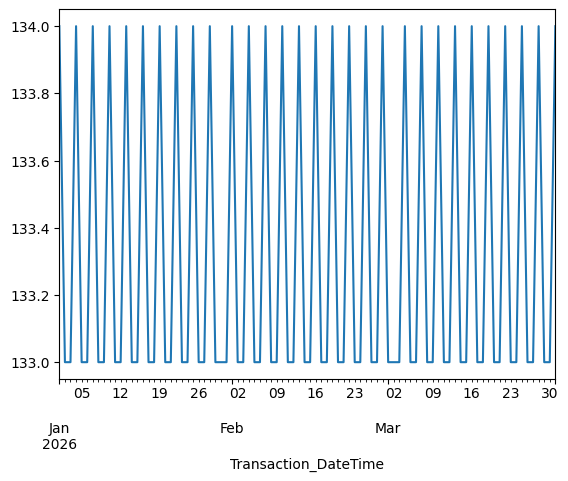

In [19]:
# 1. Confirming the date range
print(df2['Transaction_DateTime'].min())
print(df2['Transaction_DateTime'].max())

# 2. Checking if the data is already sorted by time 
print(df2['Transaction_DateTime'].is_monotonic_increasing)

# 3. Volume over time (daily count) is it steady or spiky?
df2.set_index('Transaction_DateTime').resample('D').size().plot()

# 4. Exact duplicate timestamps
print(df2['Transaction_DateTime'].duplicated().sum())

In [23]:
df2.set_index('Transaction_DateTime').resample('D').size().reset_index()['Transaction_DateTime'].dt.day_name()

0     Thursday
1       Friday
2     Saturday
3       Sunday
4       Monday
        ...   
85      Friday
86    Saturday
87      Sunday
88      Monday
89     Tuesday
Name: Transaction_DateTime, Length: 90, dtype: str

In [24]:
#checking if certain weekdays consistently run high or lower

daily = df2.set_index('Transaction_DateTime').resample('D').size().reset_index()
daily.columns = ['date', 'count']
daily['weekday'] = daily['date'].dt.day_name()

print(daily.groupby('weekday')['count'].mean().sort_values())

weekday
Friday       133.230769
Monday       133.230769
Thursday     133.307692
Tuesday      133.307692
Saturday     133.384615
Sunday       133.384615
Wednesday    133.500000
Name: count, dtype: float64
